# Prix de l'immobilier en Île-de-France

Prédiction du prix de vente à partir des caractéristiques du bien.
Pipeline : chargement → nettoyage → contrôles métier → exploration → encodage → modélisation → export.

**Données** : annonces de vente en Île-de-France (27 communes, 8 départements).

## 1. Imports et configuration

In [1]:
%pip install -q pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

plt.rcParams["figure.figsize"] = (14, 7)
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 10

## 2. Chargement

In [4]:
FICHIER = "ventes_idf.csv"   # bascule sur "ventes_idf.csv" si tu n'as pas la v3

df_brut = pd.read_csv(FICHIER)
print(df_brut.shape)
df_brut.head()

(4917, 15)


,id_annonce,type_surface,disponibilite,ville,quartier,departement,region,typologie,residence,surface_m2,salles_de_bain,balcons,dpe,prix_eur,prix_m2_eur
0,V02721,Surface Carrez,Libre immediatement,Paris,Le Marais,75,Ile-de-France,T3,Carre du Lac,55.3,2.0,0.0,D,642000.0,11609.0
1,V14279,Surface Carrez,fevr-2028,Massy,Vilmorin,91,Ile-de-France,T2,Carre des Lilas,36.8,1.0,0.0,B,159000.0,4321.0
2,V08296,Surface Carrez,Libre immediatement,Montreuil,Bel-Air,93,Ile-de-France,T5,Le Domaine Saint-Martin,175.5,1.0,0.0,C,580000.0,3305.0
3,V02123,Surface Carrez,Libre immediatement,Paris,Gobelins,75,Ile-de-France,T2,NaN,58.5,1.0,NaN,E,511000.0,8735.0
4,V12344,Surface Carrez,Libre immediatement,Meaux,Colbert,77,Ile-de-France,T2,Residence du Parc,42.5,1.0,1.0,C,97000.0,2282.0


In [5]:
df_brut.info()

<class 'pandas.DataFrame'>
RangeIndex: 4917 entries, 0 to 4916
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_annonce      4917 non-null   str    
 1   type_surface    4917 non-null   str    
 2   disponibilite   4917 non-null   str    
 3   ville           4917 non-null   str    
 4   quartier        4915 non-null   str    
 5   departement     4917 non-null   int64  
 6   region          4917 non-null   str    
 7   typologie       4911 non-null   str    
 8   residence       3120 non-null   str    
 9   surface_m2      4917 non-null   str    
 10  salles_de_bain  4892 non-null   float64
 11  balcons         4668 non-null   float64
 12  dpe             4819 non-null   str    
 13  prix_eur        4917 non-null   float64
 14  prix_m2_eur     4838 non-null   float64
dtypes: float64(4), int64(1), str(10)
memory usage: 1008.0 KB


## 3. Nettoyage

Quatre opérations, dans cet ordre :

1. **Suppression des colonnes inutiles.** `id_annonce`, `type_surface`, `disponibilite` et `residence` n'apportent rien au prix. `region` est constante (Île-de-France). `prix_m2_eur` est retiré car dérivé de la cible — le garder serait une **fuite de cible**.
2. **Doublons.**
3. **Parsing de `surface_m2`**, stockée en texte avec trois formats parasites : fourchettes (`68 - 82`), pieds carrés (`464 pi2`), ares (`1.15 are`).
4. **Extraction du nombre de pièces** depuis `typologie` (`T3` → 3, `Maison 4 pieces` → 4).

In [6]:
def parse_surface(x):
    """Convertit surface_m2 (texte) en m2 numeriques."""
    if pd.isna(x):
        return np.nan
    s = str(x).replace(',', '.')
    if 'are' in s:                      # 1.15 are -> 115 m2
        return float(re.findall(r'[\d.]+', s)[0]) * 100
    if 'pi2' in s:                      # pieds carres -> m2
        return float(re.findall(r'[\d.]+', s)[0]) / 10.7639
    if '-' in s:                        # "68 - 82" -> moyenne
        a, b = [float(v) for v in s.split('-')]
        return (a + b) / 2
    try:
        return float(s)
    except ValueError:
        return np.nan


A_SUPPRIMER = ['id_annonce', 'type_surface', 'disponibilite',
               'region', 'residence', 'prix_m2_eur']

df = (df_brut
      .drop(columns=A_SUPPRIMER)
      .drop_duplicates())

df['surface'] = df.surface_m2.apply(parse_surface)
df['pieces'] = df.typologie.str.extract(r'(\d+)').astype(float)
df = df.drop(columns=['surface_m2', 'typologie']).dropna()

df['pieces'] = df.pieces.astype(int)
df['departement'] = df.departement.astype(str)   # code, pas une grandeur ordonnee

print(f"{len(df_brut)} -> {len(df)} lignes ({(1-len(df)/len(df_brut))*100:.1f} % retirees)")
df.head()

4917 -> 4526 lignes (8.0 % retirees)


,ville,quartier,departement,salles_de_bain,balcons,dpe,prix_eur,surface,pieces
0,Paris,Le Marais,75,2.0,0.0,D,642000.0,55.3,3
1,Massy,Vilmorin,91,1.0,0.0,B,159000.0,36.8,2
2,Montreuil,Bel-Air,93,1.0,0.0,C,580000.0,175.5,5
4,Meaux,Colbert,77,1.0,1.0,C,97000.0,42.5,2
5,Versailles,Saint-Louis,78,3.0,2.0,D,729000.0,106.1,4


In [7]:
# controle : plus aucun NaN, plus aucun doublon, plus aucune colonne texte non encodee
print("NaN      :", df.isna().sum().sum())
print("doublons :", df.duplicated().sum())
print("objets   :", df.select_dtypes(['object', 'string']).columns.tolist())

NaN      : 0
doublons : 0
objets   : ['ville', 'quartier', 'departement', 'dpe']


## 4. Contrôles métier

Un filtre statistique ne remplace pas une règle du domaine. Ici : **le nombre de salles de bain ne peut pas dépasser `pièces − 1`** — un T4 est un séjour plus trois chambres, cinq salles d'eau n'y tiennent pas.

C'est plus pertinent qu'un écrêtage à ±1σ, qui supprimerait Neuilly et Paris au motif qu'ils sont chers.

In [8]:
plafond_sdb = df.pieces.clip(lower=2) - 1
n_incoherentes = int((df.salles_de_bain > plafond_sdb).sum())

df = df[df.salles_de_bain <= plafond_sdb]
print(f"salles de bain incoherentes retirees : {n_incoherentes}")
print(f"jeu final : {df.shape}")

salles de bain incoherentes retirees : 0
jeu final : (4526, 9)


## 5. Exploration

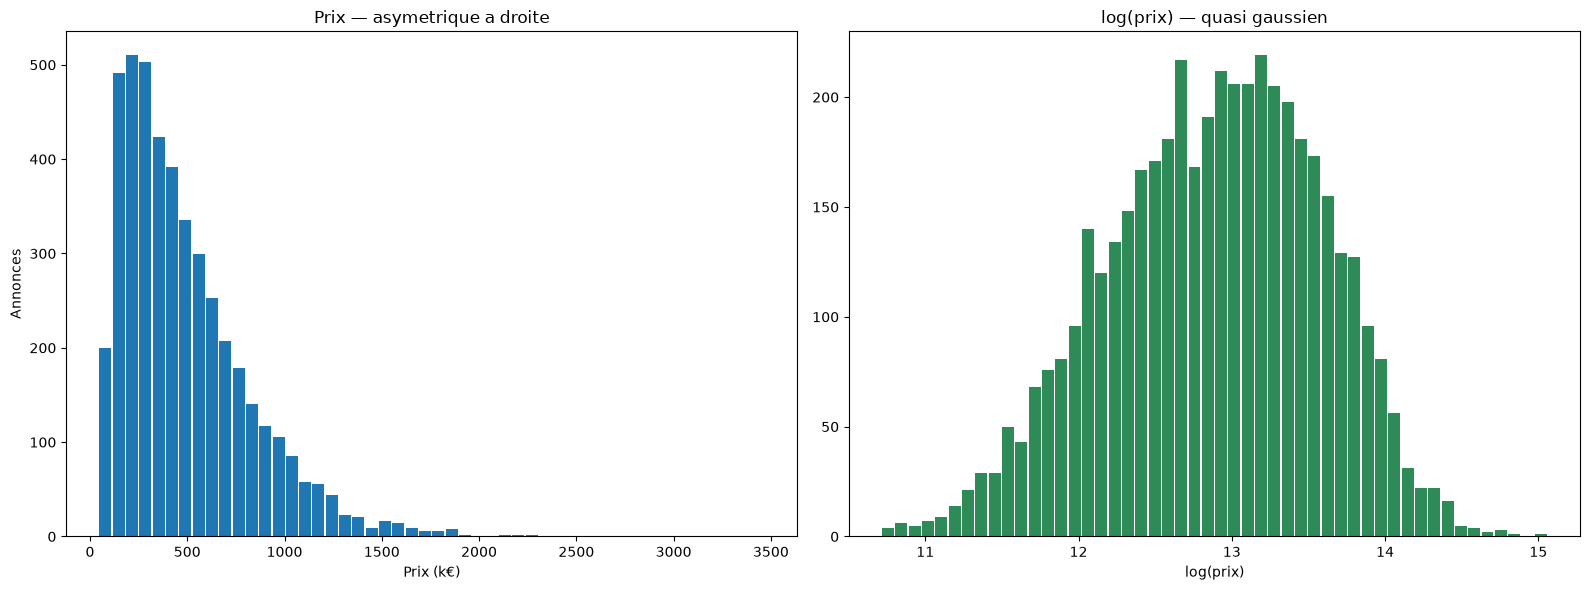

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].hist(df.prix_eur / 1000, bins=50, rwidth=0.9)
ax[0].set_xlabel("Prix (k€)"); ax[0].set_ylabel("Annonces"); ax[0].set_title("Prix — asymetrique a droite")

ax[1].hist(np.log(df.prix_eur), bins=50, rwidth=0.9, color='seagreen')
ax[1].set_xlabel("log(prix)"); ax[1].set_title("log(prix) — quasi gaussien")
plt.tight_layout(); plt.show()

La distribution des prix est fortement asymétrique, celle du log ne l'est pas. C'est le premier indice que le prix se modélise mieux en échelle logarithmique — on le vérifiera chiffres à l'appui plus loin.

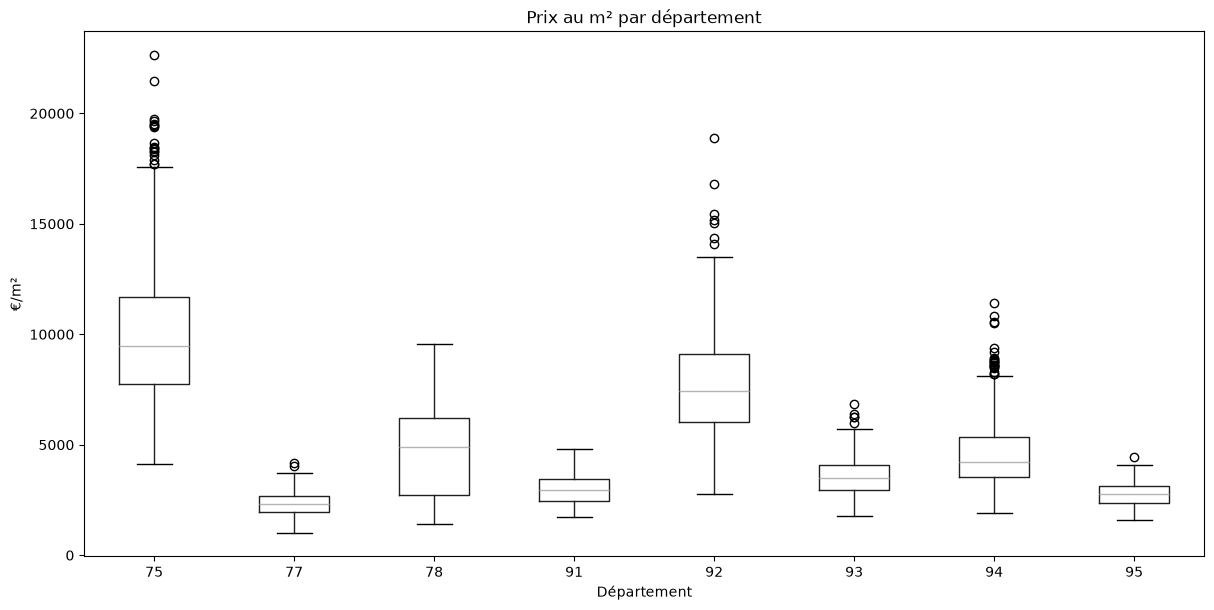

ville
Neuilly-sur-Seine        10662.0
Paris                     9479.0
Levallois-Perret          9084.0
Boulogne-Billancourt      8231.0
Issy-les-Moulineaux       7534.0
Montrouge                 7200.0
Vincennes                 7123.0
Saint-Germain-en-Laye     6235.0
Versailles                5889.0
Nanterre                  5178.0
dtype: float64

In [10]:
prix_m2 = df.prix_eur / df.surface
ordre = prix_m2.groupby(df.departement).median().sort_values(ascending=False).index

df.assign(prix_m2=prix_m2).boxplot(column='prix_m2', by='departement', grid=False)
plt.suptitle(''); plt.title("Prix au m² par département")
plt.ylabel("€/m²"); plt.xlabel("Département"); plt.show()

prix_m2.groupby(df.ville).median().sort_values(ascending=False).head(10).round(0)

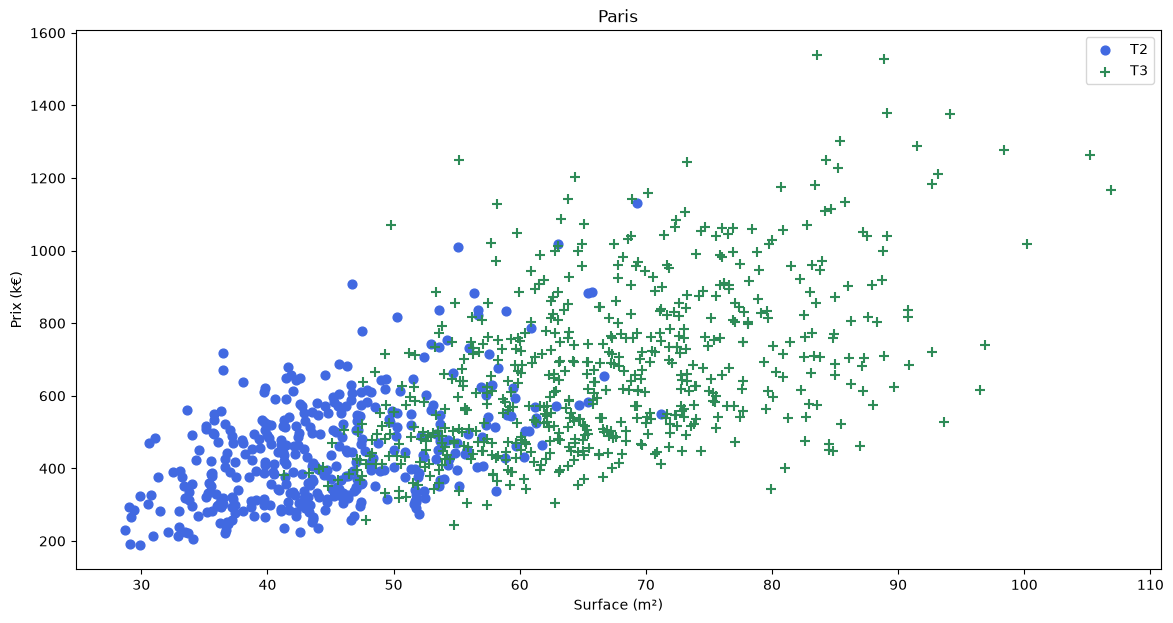

In [11]:
def nuage_typologies(df, ville, p1=2, p2=3):
    a = df[(df.ville == ville) & (df.pieces == p1)]
    b = df[(df.ville == ville) & (df.pieces == p2)]
    plt.scatter(a.surface, a.prix_eur / 1000, color='royalblue', label=f'T{p1}', s=40)
    plt.scatter(b.surface, b.prix_eur / 1000, color='seagreen', marker='+', label=f'T{p2}', s=60)
    plt.xlabel("Surface (m²)"); plt.ylabel("Prix (k€)"); plt.title(ville); plt.legend(); plt.show()

nuage_typologies(df, "Paris")

## 6. Encodage

Trois variables catégorielles : `ville` (27), `quartier` (~100), `departement` (8), plus `dpe` (7).

`drop_first=True` retire une modalité par variable pour éviter la **colinéarité parfaite** : si toutes les colonnes ville valent 0, c'est nécessairement la commune de référence.

In [12]:
CATEGORIELLES = ['ville', 'quartier', 'departement', 'dpe']

X = pd.get_dummies(df.drop(columns=['prix_eur']),
                   columns=CATEGORIELLES, drop_first=True, dtype=int)
y = df.prix_eur

print("X :", X.shape, "| y :", y.shape)
print("variables numeriques :", [c for c in X.columns if not c.startswith(tuple(m + '_' for m in CATEGORIELLES))])

X : (4526, 143) | y : (4526,)
variables numeriques : ['salles_de_bain', 'balcons', 'surface', 'pieces']


## 7. Choix de la cible : prix ou log(prix) ?

Le prix immobilier se forme de façon **multiplicative** — un m² supplémentaire ne vaut pas le même montant à Neuilly et à Meaux. Une régression linéaire additionne des effets, elle ne peut pas représenter ça. Passer la cible en log transforme le produit en somme.

In [13]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

score_brut = cross_val_score(LinearRegression(), X, y, cv=cv)
score_log = cross_val_score(LinearRegression(), X, np.log(y), cv=cv)

print(f"prix brut : {score_brut.mean():.4f} ± {score_brut.std():.4f}   {score_brut.round(4)}")
print(f"log(prix) : {score_log.mean():.4f} ± {score_log.std():.4f}   {score_log.round(4)}")

prix brut : 0.8221 ± 0.0112   [0.8296 0.838  0.8111 0.8081 0.8238]
log(prix) : 0.9293 ± 0.0013   [0.9308 0.9295 0.9273 0.9303 0.9287]


### Apport de chaque variable géographique

Le département est entièrement déterminé par la commune. On vérifie s'il apporte quelque chose.

In [14]:
resultats = []
for cols in [['ville'], ['departement'], ['ville', 'departement']]:
    Xv = pd.get_dummies(df.drop(columns=['prix_eur']),
                        columns=cols + ['quartier', 'dpe'], drop_first=True, dtype=int)
    Xv = Xv.select_dtypes(exclude=['object', 'string'])
    s = cross_val_score(LinearRegression(), Xv, np.log(y), cv=cv)
    resultats.append({'variables': ' + '.join(cols), 'colonnes': Xv.shape[1], 'R2': round(s.mean(), 4)})

pd.DataFrame(resultats)

,variables,colonnes,R2
0,ville,136,0.9293
1,departement,117,0.9163
2,ville + departement,143,0.9293


`ville` et `ville + departement` donnent le même score : le département est **redondant**, il coûte des colonnes sans rien apporter. On le conserve ici parce qu'il reste lisible pour l'analyse, mais il pourrait être retiré sans perte.

## 8. Comparaison des algorithmes

In [15]:
def comparer_modeles(X, y, cv):
    algos = {
        'linear_regression': (LinearRegression(), {'fit_intercept': [True, False]}),
        'ridge':             (Ridge(), {'alpha': [0.01, 0.1, 1, 10]}),
        'lasso':             (Lasso(max_iter=10000), {'alpha': [0.0001, 0.001, 0.01]}),
        'decision_tree':     (DecisionTreeRegressor(random_state=RANDOM_STATE),
                              {'criterion': ['squared_error'], 'max_depth': [None, 10, 20]}),
        'random_forest':     (RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
                              {'max_depth': [None, 20]}),
    }
    lignes = []
    for nom, (modele, grille) in algos.items():
        gs = GridSearchCV(modele, grille, cv=cv, n_jobs=-1).fit(X, y)
        lignes.append({'modele': nom,
                       'R2': round(gs.best_score_, 4),
                       'meilleurs_parametres': gs.best_params_})
    return pd.DataFrame(lignes).sort_values('R2', ascending=False).reset_index(drop=True)

comparer_modeles(X, np.log(y), cv)

,modele,R2,meilleurs_parametres
0,ridge,0.9295,{'alpha': 1}
1,linear_regression,0.9293,{'fit_intercept': False}
2,lasso,0.9293,{'alpha': 0.0001}
3,random_forest,0.9264,{'max_depth': 20}
4,decision_tree,0.8766,"{'criterion': 'squared_error', 'max_depth': 10}"


Les modèles linéaires régularisés arrivent en tête et devancent le Random Forest. C'est la confirmation du diagnostic : une fois la cible passée en log, la relation est linéaire, et un modèle à base d'arbres n'a plus d'avantage à offrir.

## 9. Évaluation en euros

Un R² sur `log(prix)` n'est pas comparable à un R² sur `prix`. On ramène les prédictions en euros pour obtenir une erreur interprétable.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, np.log(y), test_size=0.2, random_state=RANDOM_STATE)

modele = LinearRegression().fit(X_train, y_train)

reel = np.exp(y_test)
predit = np.exp(modele.predict(X_test))

print(f"R²   : {r2_score(reel, predit):.4f}")
print(f"MAE  : {mean_absolute_error(reel, predit):,.0f} €")
print(f"MAPE : {(np.abs(reel - predit) / reel).mean() * 100:.1f} %")

R²   : 0.8177
MAE  : 73,918 €
MAPE : 15.4 %


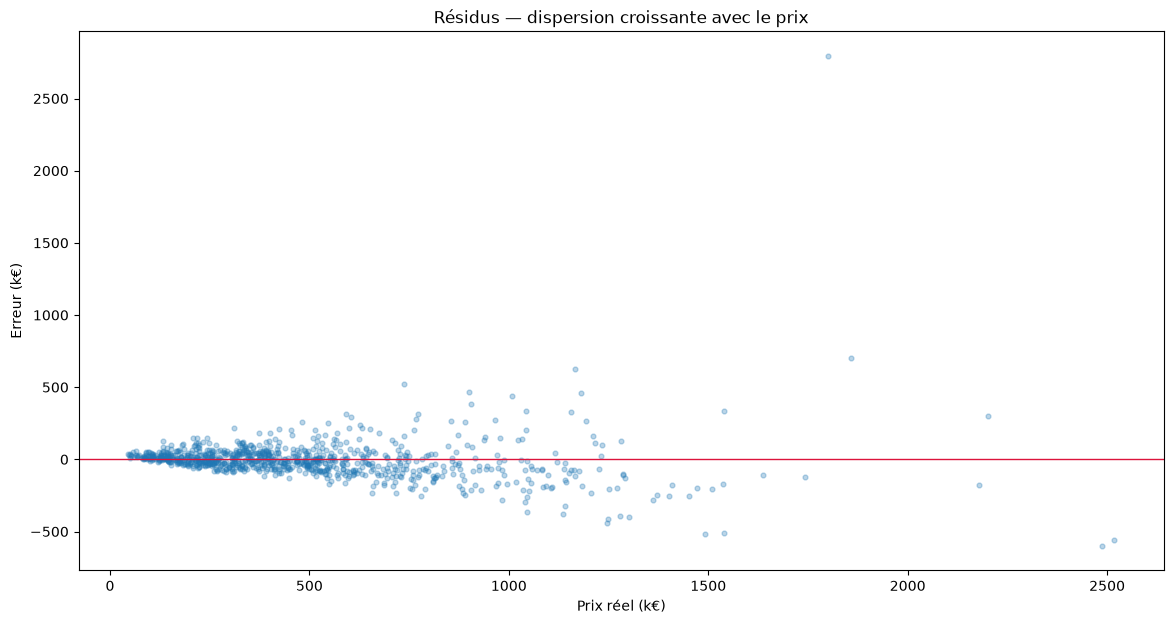

In [17]:
erreur = predit - reel
plt.scatter(reel / 1000, erreur / 1000, alpha=0.3, s=12)
plt.axhline(0, color='crimson', lw=1)
plt.xlabel("Prix réel (k€)"); plt.ylabel("Erreur (k€)")
plt.title("Résidus — dispersion croissante avec le prix"); plt.show()

## 10. Fonction de prédiction

In [18]:
modele_final = LinearRegression().fit(X, np.log(y))
COLONNES = list(X.columns)


def predire_prix(ville, quartier, departement, surface, pieces,
                 salles_de_bain=1, balcons=0, dpe='D'):
    """Prix estime en euros. Renvoie une erreur si la commune ou le quartier est inconnu."""
    x = np.zeros(len(COLONNES))
    for nom, valeur in [('surface', surface), ('pieces', pieces),
                        ('salles_de_bain', salles_de_bain), ('balcons', balcons)]:
        x[COLONNES.index(nom)] = valeur

    # une modalite absente est soit la reference retiree par drop_first (rien a activer),
    # soit une valeur inconnue du modele
    for colonne in [f'ville_{ville}', f'quartier_{quartier}',
                    f'departement_{departement}', f'dpe_{dpe}']:
        if colonne in COLONNES:
            x[COLONNES.index(colonne)] = 1

    return float(np.exp(modele_final.predict(pd.DataFrame([x], columns=COLONNES))[0]))

In [19]:
# meme bien (T3, 65 m2, DPE C) dans cinq quartiers differents
biens = [("Neuilly-sur-Seine", "Sablons", "92"),
         ("Paris", "Le Marais", "75"),
         ("Paris", "Belleville", "75"),
         ("Saint-Denis", "Pleyel", "93"),
         ("Trappes", "Village", "78")]

for ville, quartier, dep in biens:
    prix = predire_prix(ville, quartier, dep, surface=65, pieces=3, salles_de_bain=1, balcons=1, dpe='C')
    print(f"{ville:20} {quartier:14} {prix:>10,.0f} €   ({prix/65:>6,.0f} €/m²)")

Neuilly-sur-Seine    Sablons           682,030 €   (10,493 €/m²)
Paris                Le Marais         764,236 €   (11,757 €/m²)
Paris                Belleville        460,503 €   ( 7,085 €/m²)
Saint-Denis          Pleyel            215,419 €   ( 3,314 €/m²)
Trappes              Village           186,595 €   ( 2,871 €/m²)


Le modèle a bien appris la géographie : à caractéristiques identiques, l'écart va de 1 à 4 entre Trappes et Le Marais.

## 11. Export du modèle

In [20]:
with open('modele_prix_idf.pickle', 'wb') as f:
    pickle.dump(modele_final, f)

with open('colonnes.json', 'w') as f:
    json.dump({'colonnes': COLONNES,
               'villes': sorted(df.ville.unique().tolist()),
               'quartiers': sorted(df.quartier.unique().tolist()),
               'cible': 'log(prix_eur)'}, f, indent=2, ensure_ascii=False)

print("modele_prix_idf.pickle et colonnes.json ecrits")

modele_prix_idf.pickle et colonnes.json ecrits


## Synthèse

| Étape | Résultat |
|---|---|
| Lignes après nettoyage | ~4 500 sur 4 917 |
| Variables après encodage | 143 |
| R² validation croisée (5 folds) | **0,929 ± 0,002** |
| Erreur absolue moyenne | ~74 000 € |
| Erreur relative moyenne | ~15 % |

**Trois décisions qui portent le résultat :**

1. **Cible en log** — +12 points de R². Le prix est multiplicatif, pas additif.
2. **Quartier conservé** — +4,6 points. C'est la variable la plus discriminante après la commune : dans Paris seul, l'écart va de 1 à 2 entre Porte de Clignancourt et Saint-Germain-des-Prés.
3. **Fuite de cible évitée** — `prix_m2_eur` retiré dès le nettoyage. L'y laisser donnerait un R² proche de 1 sans aucune valeur prédictive.

**Limite à connaître** : ces données sont synthétiques. Le modèle apprend la formule qui les a générées, pas le marché réel. Pour une version exploitable, la source à utiliser est **DVF** (data.gouv.fr), qui recense les mutations réelles depuis 2014.

In [1]:
%pip install fastapi "uvicorn[standard]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.1 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 6.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [fastapi]3/14 [fastapi]]]]oc]s]n]
Note: you may need to restart the kernel to use updated packages.
